This file can be used to compute W2 (MW11) = FvoigtHCD (Tan25) following two methods.

We will use MW21 cosmology and redshift

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from picca import constants
import h5py
from scipy import constants as scipy_constants

import sys
import os
sys.path.append(os.path.abspath(".."))
from w1_w2 import wave_to_fft_profile, compute_w1_w2

In [3]:
# MW21 cosmology values
hubble, z = 0.71, 2.5
omegab, omegam = 0.046, 0.27
omegal = 1 - omegam
ns = 0.96

NHirange = np.linspace(17.2, 20.3) # To be consistent with ASTRID maxNHi considered
c_kms = constants.speed_light*1e-3  # kms^-1
conversion_factor = 100*hubble*((1+z)**2)/c_kms

wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log

# 1. MW11

## 1.1 - f(NHi, X) 

In [4]:
def f_Nhi(colden, k, b):
    y = k*(colden**b)
    return y

The parameters b1 and b2 are given in the paper. k1 and k2 are determinated so that:
- the integration of f_nhi from logNhi=19 to logNhi=20.3 (cm^-2) is 0.1
- f_Nhi(k1, b1) = f_Nhi(k2, b2) at logNhi = 20.3

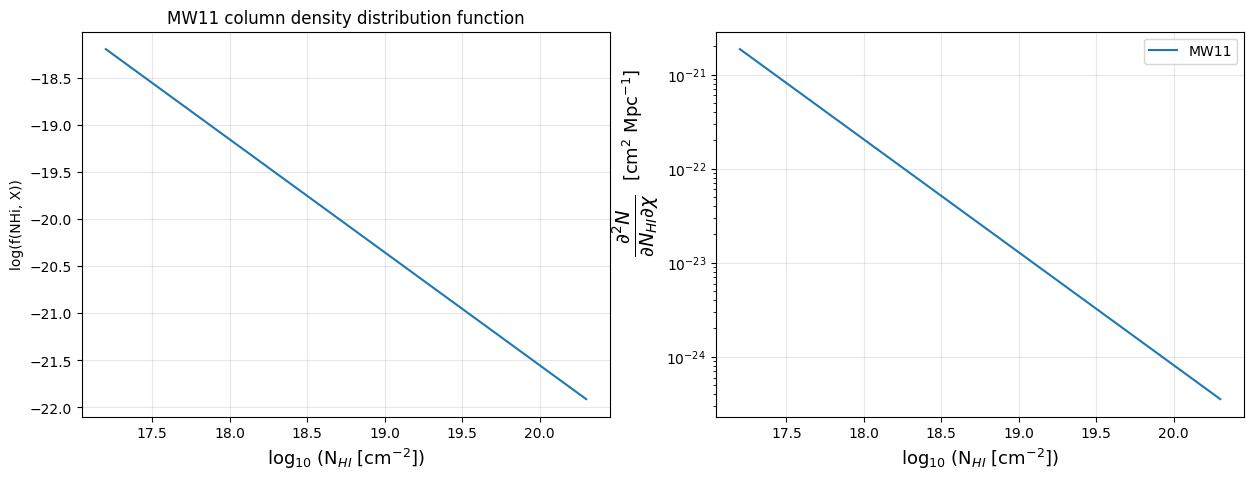

In [5]:
k1, b1 = 280.14, -1.2
k2, b2 = 4.24e14, -1.8

colden1, colden2 = NHirange[NHirange < 20.3], NHirange[NHirange >= 20.3]
fNhi_mw11 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])
cddf_mw11 = fNhi_mw11*conversion_factor

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(NHirange, np.log10(fNhi_mw11))
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel('log(f(NHi, X))')
plt.title('MW11 column density distribution function')
plt.grid(alpha=0.3);

plt.subplot(1, 2, 2)
plt.plot(NHirange, cddf_mw11, label='MW11')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial^2 N}{\partial N_{HI}\partial \chi}$', fontsize=20)
plt.text(-0.18, 0.63, r'[cm$^2$ Mpc$^{-1}$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend();


## 1.2 - f(n)

In [6]:
fn_mw11 = []
for i in np.arange(len(NHirange)):
    fn_mw11.append(fNhi_mw11[i] * 10**(NHirange[i]))
fn_mw11 = np.array(fn_mw11) * np.log(10)
norm_mw11 = np.trapezoid(fn_mw11, NHirange)
fn_mw11 /= norm_mw11

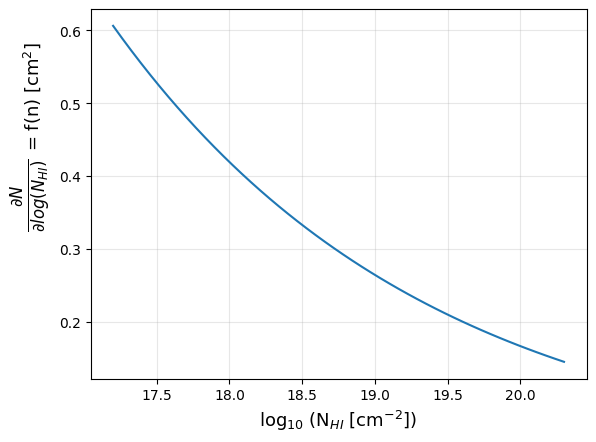

In [7]:
plt.plot(NHirange, fn_mw11)
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial N}{\partial log(N_{HI})}$', fontsize=17)
plt.text(-0.14, 0.63, r'= f(n) [cm$^2$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.grid(alpha=0.3);

## 1.3 - W2 = Fvoigt?

In [8]:
inte = []
for i in np.arange(len(NHirange)):
    inte.append(fNhi_mw11[i]*np.log(10)*(10**(NHirange[i])))
inte = np.array(inte)    
lX_mw11 = np.trapezoid(inte, NHirange)
rho_mw11 = lX_mw11*100*hubble*((1+z)**2)/c_kms

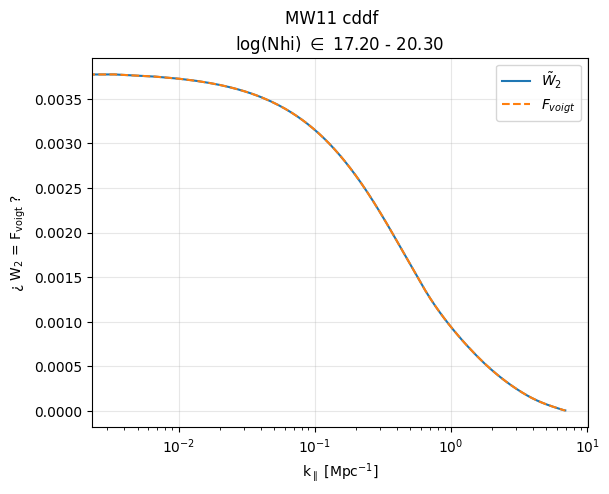

In [9]:
w2, Fvoigt = [], []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)  # k is in h/Mpc and d in Mpc/h
    k_w1w2 /= hubble
    d *= hubble
    # MW11 procedure
    w2.append(cddf_mw11[i]*d*np.log(10)*(10**nhi_value))
    # Tan25 procedure
    Fvoigt.append(fn_mw11[i]*d)

    
w2, Fvoigt = np.array(w2), np.array(Fvoigt)
#w2_mw11 = np.trapezoid(w2, NHirange, axis=0)/Fmean_hcd  # Correction suggested in Tan25
w2_mw11 = np.trapezoid(w2, NHirange, axis=0)
Fvoigt_mw11 = np.trapezoid(Fvoigt, NHirange, axis=0)*rho_mw11

plt.plot(k_w1w2, w2_mw11, label=r'$\tilde{W}_2$')
plt.plot(k_w1w2, Fvoigt_mw11, linestyle='--', label=r'$F_{voigt}$')
plt.ylabel(r'¿ W$_2$ = F$_\text{voigt}$ ?')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))
plt.suptitle('MW11 cddf');

# 2. pyIGM

## 2.1 - f(NHi, X)

In [9]:
data = '/Users/lflores/Documents/Research/phd/hcd/data/fNHi/fn_pyigm1'

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    print('----------------') 
    print('Data:')
    print(f.keys())

    fNhi_pyigm = 10**(f['fn'][:])

cddf_pyigm = fNhi_pyigm*conversion_factor

Atributes:
Redshift = 2.5
logNHI_max = 21.3
logNHI_min = 17.2
----------------
Data:
<KeysViewHDF5 ['fn', 'logNhi']>


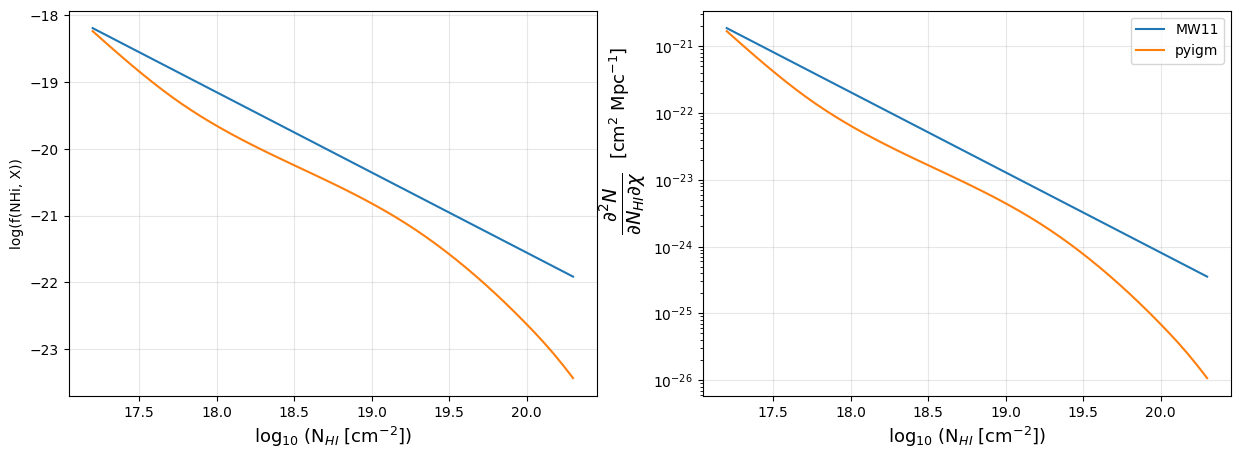

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(NHirange, np.log10(fNhi_mw11), label='MW11')
plt.plot(NHirange, np.log10(fNhi_pyigm), label='pyigm')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel('log(f(NHi, X))')
plt.grid(alpha=0.3);

plt.subplot(1, 2, 2)
plt.plot(NHirange, cddf_mw11, label='MW11')
plt.plot(NHirange, cddf_pyigm, label='pyigm')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial^2 N}{\partial N_{HI}\partial \chi}$', fontsize=20)
plt.text(-0.18, 0.63, r'[cm$^2$ Mpc$^{-1}$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend();

## 2.2 - f(n) 

In [11]:
fn_pyigm = []
for i in np.arange(len(NHirange)):
    fn_pyigm.append(fNhi_pyigm[i] * 10**(NHirange[i]))
fn_pyigm = np.array(fn_pyigm) * np.log(10)
norm_pyigm = np.trapezoid(fn_pyigm[:, 0], NHirange)
fn_pyigm /= norm_pyigm

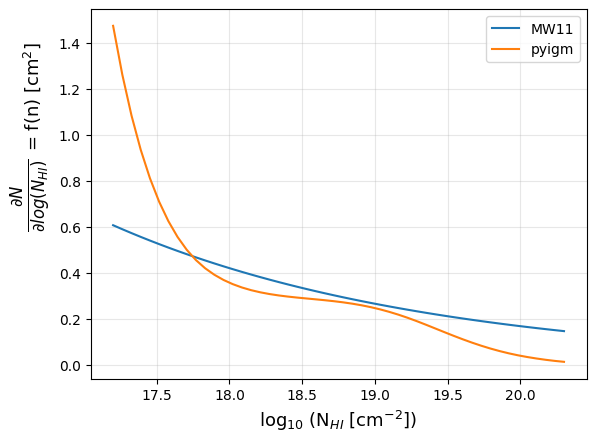

In [12]:
plt.plot(NHirange, fn_mw11, label='MW11')
plt.plot(NHirange, fn_pyigm, label='pyigm')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial N}{\partial log(N_{HI})}$', fontsize=17)
plt.text(-0.14, 0.63, r'= f(n) [cm$^2$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.grid(alpha=0.3)
plt.legend();

## 2.3 - W2 = Fvoigt?

In [13]:
inte = []
for i in np.arange(len(NHirange)):
    inte.append(fNhi_pyigm[:, 0][i]*np.log(10)*(10**(NHirange[i])))
inte = np.array(inte)    
lX_pyigm = np.trapezoid(inte, NHirange)
rho_pyigm = lX_pyigm*100*hubble*((1+z)**2)/c_kms

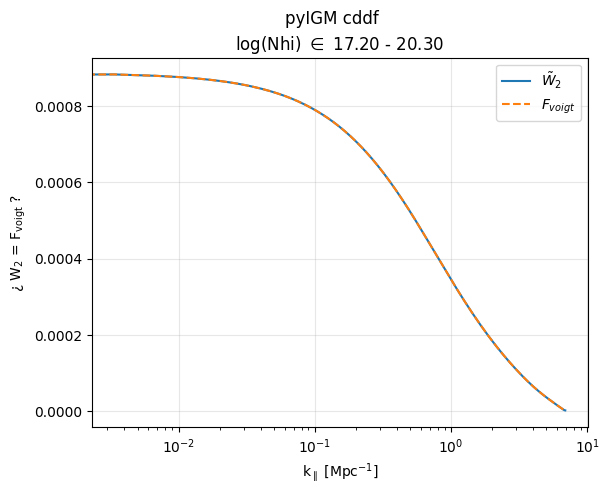

In [14]:
w2, Fvoigt = [], []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)  # k is in h/Mpc and d in Mpc/h
    k_w1w2 /= hubble
    d *= hubble
    # MW11 procedure
    w2.append(cddf_pyigm[i]*d*np.log(10)*(10**nhi_value))
    # Tan25 procedure
    Fvoigt.append(fn_pyigm[i]*d)

    
w2, Fvoigt = np.array(w2), np.array(Fvoigt)
w2_pyigm = np.trapezoid(w2, NHirange, axis=0)  # Correction suggested in Tan25
Fvoigt_pyigm = np.trapezoid(Fvoigt, NHirange, axis=0)*rho_pyigm

plt.plot(k_w1w2, w2_pyigm, label=r'$\tilde{W}_2$')
plt.plot(k_w1w2, Fvoigt_pyigm, linestyle='--', label=r'$F_{voigt}$')
plt.ylabel(r'¿ W$_2$ = F$_\text{voigt}$ ?')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))
plt.suptitle('pyIGM cddf');

# 3. ASTRID

In [15]:
data_on = '/Users/lflores/Documents/Research/phd/hcd/data/ASTRID/spectra_ASTRID_z2.5_500x500x2500.hdf5'  # With self-shielding

with h5py.File(data_on, 'r') as f:
    print('Keys:', f.keys())
    header_on = f['Header']
    print('------ Header ------')
    for attr in header_on.attrs:
            print(f"{attr} : {header_on.attrs[attr]}")
    print('------ Data ------')
    colden = f['colden/H/1'][:]
    print('colden shape:', colden.shape)  

Keys: <KeysViewHDF5 ['Header', 'colden', 'spectra', 'tau']>
------ Header ------
Hz : 252.87249366801257
box : 250000.0
discarded : 0
hubble : 0.6774
nbins : 2500
npart : [165988309584 166375000000            0            0  10297622146
     11325619]
omegab : 0.0486
omegal : 0.6911
omegam : 0.3089
redshift : 2.499999947500001
------ Data ------
colden shape: (250000, 2500)


In [16]:
print('----- Useful information -----')
Lbox = 250  # Mpc/h
print('box size:', Lbox, 'Mpc/h')

# Number of skewers per side
Nsk = int(np.sqrt(colden.shape[0]))  # colden.on_shape[0] gives the size of the axis
print(Nsk,'skewers per side')

# Number of pixels per skewer
Np = colden.shape[1] # colden.on_shape[1] gives the size of the columns
print(Np, 'pixels per skewer')

# Pixel width 
Pw = Lbox/Np  # Mpc/h 
print(Pw, 'Mpc/h pixel width')
# We are dividing the total box width in comoving units by the number of pixels in each skewer

# Minimum separation between skewers
Ssk = Lbox/Nsk  # Mpc/h 
print(Ssk, 'Mpc/h skewer separation')
# We are dividing the total box width in comoving units by the number of skewers per side

----- Useful information -----
box size: 250 Mpc/h
500 skewers per side
2500 pixels per skewer
0.1 Mpc/h pixel width
0.5 Mpc/h skewer separation


## 3.1 - f(n)

In [17]:
colden_log = np.log10(colden[colden > 0])
counts, _ = np.histogram(colden_log, bins=NHirange)
mid_nhi = (NHirange[:-1] + (NHirange[1] - NHirange[0])/2)
dn = mid_nhi[1]-mid_nhi[0]

In [18]:
fn_astrid = np.interp(NHirange, mid_nhi, counts/dn)
norm_astrid = np.trapezoid(fn_astrid, NHirange)
fn_astrid /= norm_astrid

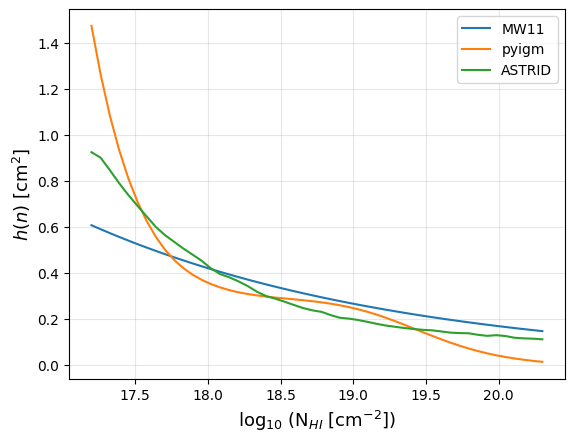

In [19]:
plt.plot(NHirange, fn_mw11, label='MW11')
plt.plot(NHirange, fn_pyigm, label='pyigm')
plt.plot(NHirange, fn_astrid, label='ASTRID')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$h(n)$ [cm$^2$]', fontsize=13)
plt.grid(alpha=0.3)
plt.legend();

## 3.2 - f(NHi, X)

In [20]:
dX = (Nsk**2)*Lbox*100*hubble*((1+z)**2)/c_kms
fnX = np.interp(NHirange, mid_nhi, counts/dn)/dX
fNhi_astrid = fnX/(np.log(10)*(10**NHirange))
cddf_astrid = fNhi_astrid*conversion_factor

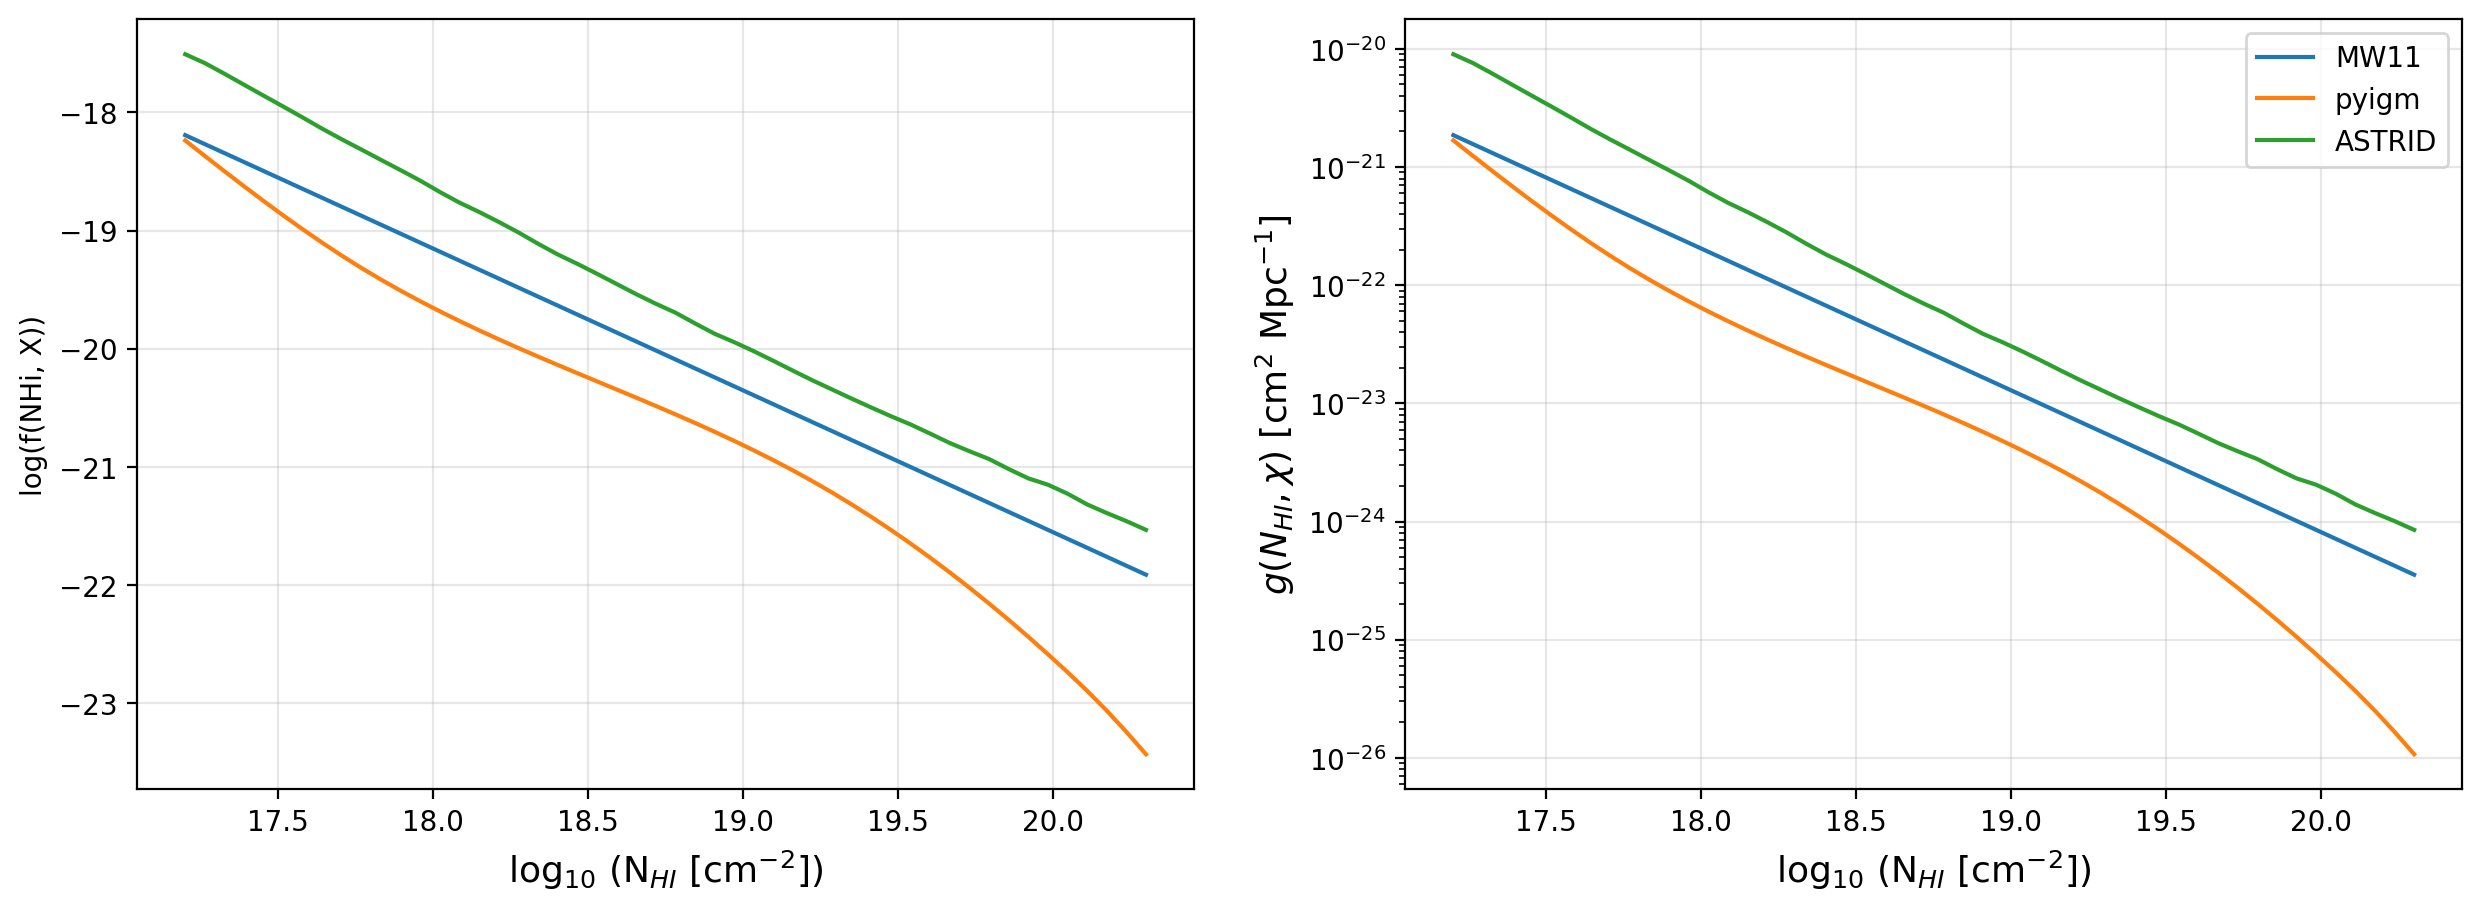

In [21]:
plt.figure(figsize=(15, 5), dpi=200)

plt.subplot(1, 2, 1)
plt.plot(NHirange, np.log10(fNhi_mw11), label='MW11')
plt.plot(NHirange, np.log10(fNhi_pyigm), label='pyigm')
plt.plot(NHirange, np.log10(fNhi_astrid), label='ASTRID')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel('log(f(NHi, X))')
plt.grid(alpha=0.3);

plt.subplot(1, 2, 2)
plt.plot(NHirange, cddf_mw11, label='MW11')
plt.plot(NHirange, cddf_pyigm, label='pyigm')
plt.plot(NHirange, cddf_astrid, label='ASTRID')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$g(N_{HI}, \chi)$ [cm$^2$ Mpc$^{-1}$]', fontsize=13)
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend();

## 3.3 - W2 = Fvoigt?

In [22]:
inte = []
for i in np.arange(len(NHirange)):
    inte.append(fNhi_astrid[i]*np.log(10)*(10**(NHirange[i])))
inte = np.array(inte)    
lX_astrid = np.trapezoid(inte, NHirange)
rho_astrid = lX_astrid*100*hubble*((1+z)**2)/c_kms

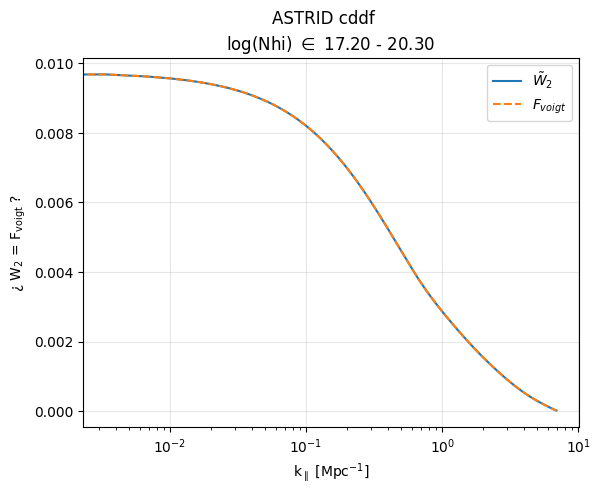

In [23]:
w2, Fvoigt = [], []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)  # k is in h/Mpc and d in Mpc/h
    k_w1w2 /= hubble
    d *= hubble
    # MW11 procedure
    w2.append(cddf_astrid[i]*d*np.log(10)*(10**nhi_value))
    # Tan25 procedure
    Fvoigt.append(fn_astrid[i]*d)

    
w2, Fvoigt = np.array(w2), np.array(Fvoigt)
w2_astrid = np.trapezoid(w2, NHirange, axis=0)
Fvoigt_astrid = np.trapezoid(Fvoigt, NHirange, axis=0)*rho_astrid

plt.plot(k_w1w2, w2_astrid, label=r'$\tilde{W}_2$')
plt.plot(k_w1w2, Fvoigt_astrid, linestyle='--', label=r'$F_{voigt}$')
plt.ylabel(r'¿ W$_2$ = F$_\text{voigt}$ ?')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))
plt.suptitle('ASTRID cddf');

# Final plots

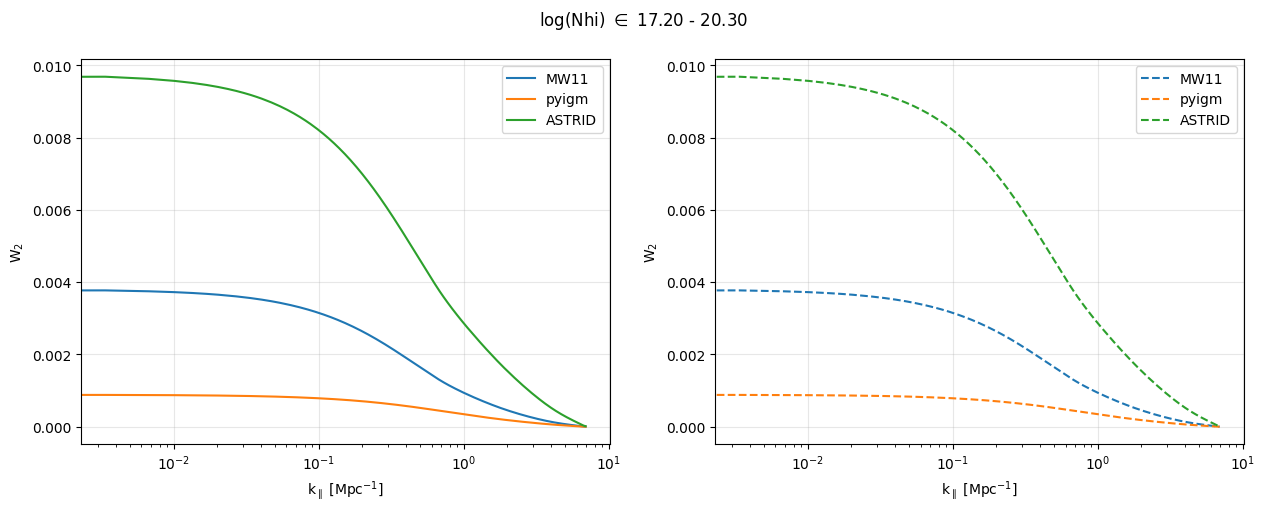

In [24]:
plt.figure(figsize=(15, 5))
plt.suptitle(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))

plt.subplot(1, 2, 1)
plt.plot(k_w1w2, w2_mw11, label='MW11')
plt.plot(k_w1w2, w2_pyigm, label='pyigm')
plt.plot(k_w1w2, w2_astrid, label='ASTRID')
plt.ylabel(r'W$_2$')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_w1w2, Fvoigt_mw11, linestyle='--', label='MW11')
plt.plot(k_w1w2, Fvoigt_pyigm, linestyle='--', label='pyigm')
plt.plot(k_w1w2, Fvoigt_astrid, linestyle='--', label='ASTRID')
plt.ylabel(r'W$_2$')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)

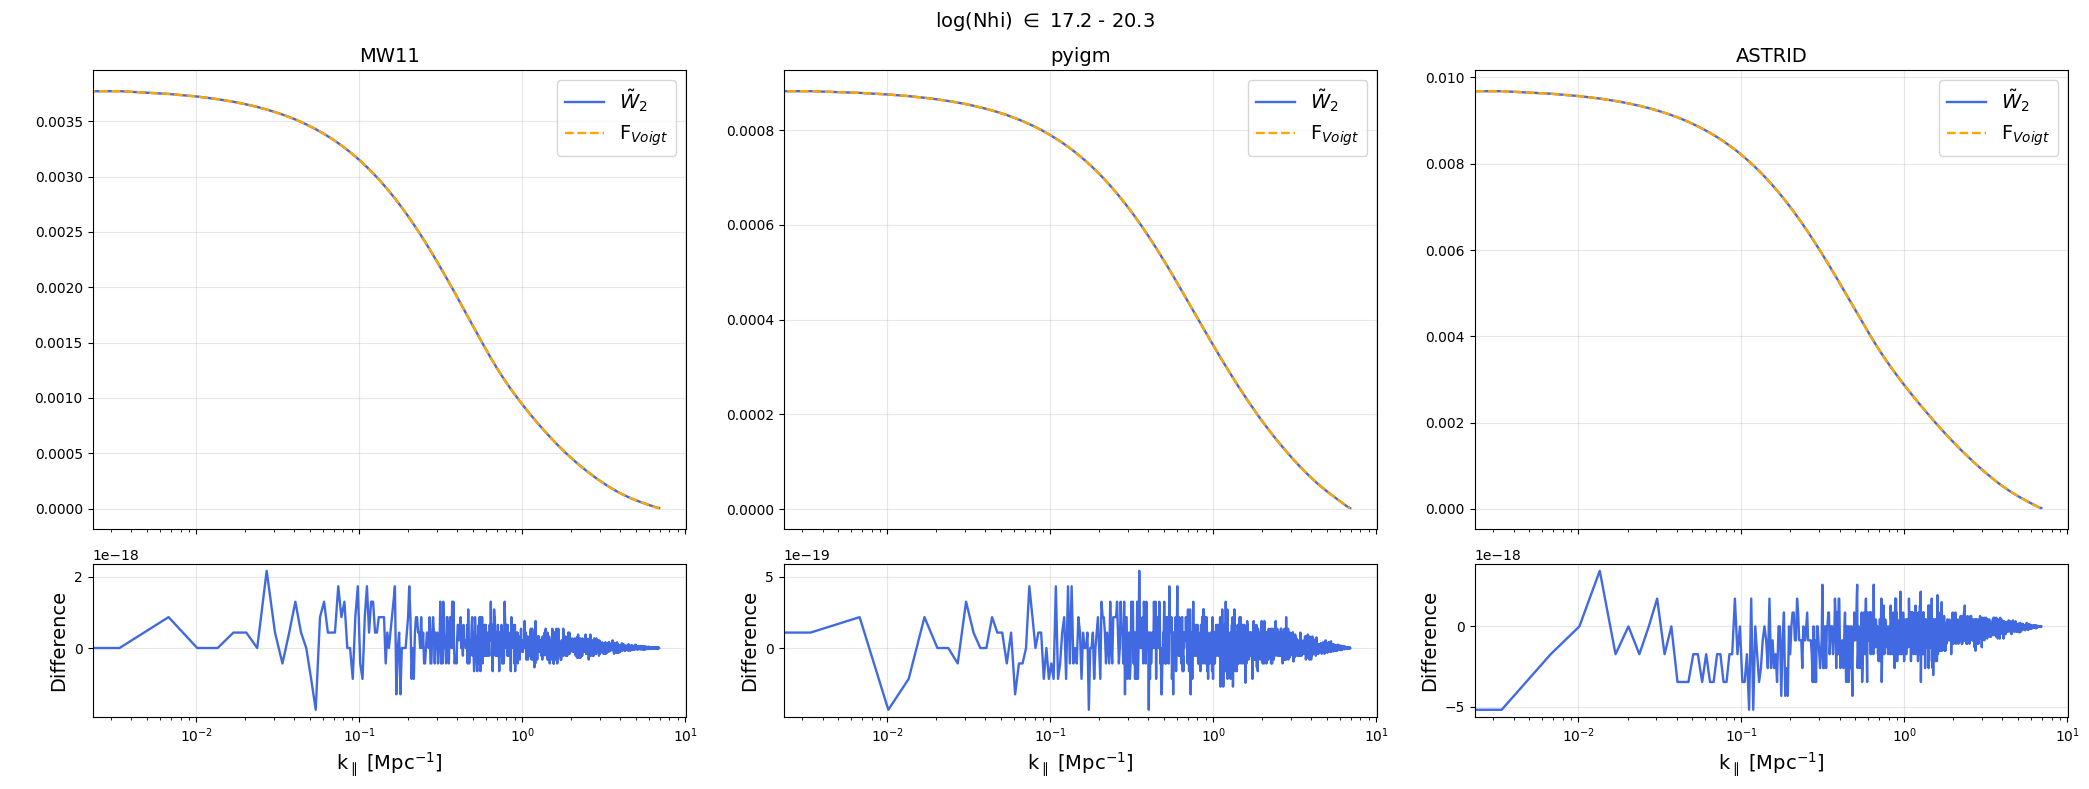

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(21, 8), sharex='col',
                         gridspec_kw={'height_ratios': [3, 1]}, )
dpi=200
plt.suptitle(r'log(Nhi) $\in$ %.1f - %.1f' %(NHirange.min(), NHirange.max()), fontsize=14)
plt.rcParams.update({'xtick.labelsize': 16, 'ytick.labelsize': 16})

# --- TOP ROW ---
# MW11
axes[0,0].plot(k_w1w2, w2_mw11, linewidth=1.7, color='royalblue', label=r'$\tilde{W}_2$')
axes[0,0].plot(k_w1w2, Fvoigt_mw11, linewidth=1.7, color='orange', linestyle='--', label=r'F$_{Voigt}$')
axes[0,0].set_xscale('log')
axes[0,0].legend(fontsize=14)
axes[0, 0].set_ylabel(' ', fontsize=14)
axes[0,0].grid(alpha=0.3)
axes[0,0].set_title('MW11', fontsize=14)

# pyIGM
axes[0,1].plot(k_w1w2, w2_pyigm, linewidth=1.7, color='royalblue', label=r'$\tilde{W}_2$')
axes[0,1].plot(k_w1w2, Fvoigt_pyigm, linewidth=1.7, color='orange', linestyle='--', label=r'F$_{Voigt}$')
axes[0,1].set_xscale('log')
axes[0,1].legend(fontsize=14)
axes[0, 1].set_ylabel(' ', fontsize=14)
axes[0,1].grid(alpha=0.3)
axes[0,1].set_title('pyigm', fontsize=14)

# ASTRID
axes[0,2].plot(k_w1w2, w2_astrid, linewidth=1.7, color='royalblue', label=r'$\tilde{W}_2$')
axes[0,2].plot(k_w1w2, Fvoigt_astrid, linewidth=1.7, color='orange', linestyle='--', label=r'F$_{Voigt}$')
axes[0,2].set_xscale('log')
axes[0,2].legend(fontsize=14)
axes[0, 2].set_ylabel(' ', fontsize=14)
axes[0,2].grid(alpha=0.3)
axes[0,2].set_title('ASTRID', fontsize=14)

# --- BOTTOM ROW (RATIOS) ---
axes[1,0].plot(k_w1w2, Fvoigt_mw11-w2_mw11, linewidth=1.7, color='royalblue')
axes[1,0].set_xscale('log')
axes[1,0].set_ylabel('Difference', fontsize=14)
axes[1,0].set_xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(k_w1w2, Fvoigt_pyigm-w2_pyigm, linewidth=1.7, color='royalblue')
axes[1,1].set_xscale('log')
axes[1,1].set_ylabel('Difference', fontsize=14)
axes[1,1].set_xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
axes[1,1].grid(alpha=0.3)

axes[1,2].plot(k_w1w2, Fvoigt_astrid-w2_astrid, linewidth=1.7, color='royalblue')
axes[1,2].set_xscale('log')
axes[1,2].set_ylabel('Difference', fontsize=14)
axes[1,2].set_xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
axes[1,2].grid(alpha=0.3)

plt.tight_layout()


In [26]:
w2_pyigm[1]*2

np.float64(0.0017641868558261173)